In [1]:
print("rohit")

rohit


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
target = "load_actual"

# Train–test split by timestamp
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

y_train = train[target]
y_test = test[target]

In [3]:
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler

# Use all features except timestamp and target
X = df.drop(columns=["timestamp", target])
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

# Scale inputs
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Best general SVR configuration
svm = SVR(kernel='rbf', C=100, gamma='scale')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

# Metrics
mae_svm = mean_absolute_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
mape_svm = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100

print("SVM MAE :", mae_svm)
print("SVM RMSE:", rmse_svm)
print("SVM MAPE:", mape_svm)

SVM MAE : 3129.2803130275734
SVM RMSE: 3963.1067673767757
SVM MAPE: 11.00806111518004


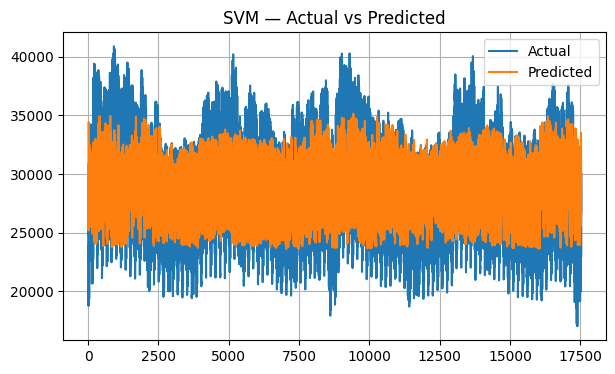

In [4]:
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_svm, label="Predicted")
plt.title("SVM — Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()